# 1. Introdução

Otimização e Tuning de Hiperparâmetros
Projeto: Credit Risk – Home Credit Default Risk
Após a avaliação de diferentes estratégias de balanceamento e algoritmos de classificação, o XGBoost apresentou o melhor desempenho geral para identificação de clientes inadimplentes.

Este notebook tem como objetivo otimizar o desempenho do modelo por meio do ajuste de hiperparâmetros, validação cruzada e calibração do limiar de classificação, buscando melhorar a capacidade de identificação da classe inadimplente sem comprometer excessivamente a precisão das previsões.

# 1.  Bibliotecas

In [21]:
# MANIPULAÇÃO DE DADOS
import pandas as pd

# GRÁFICOS
import matplotlib.pyplot as plt

# METRICAS DE DECISÃO e SMOTE para teste de balanceamento das classes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# MACHINE LEARNING
from xgboost import XGBClassifier

# 2. Carregamento dos Dados processados

Nesta etapa são carregados os dados previamente processados e utilizados nas etapas anteriores de modelagem.

In [2]:
# Features
features_processed = pd.read_parquet('../data/processed/Features_processed.parquet')
# Target
target_processed = pd.read_parquet('../data/processed/Target_processed.parquet')
# APLICANDO A FUNÇÃO RAVEL() NOS VALORES DO TARGET PARA CONVERTER PARA UM COLUNA 1D
target_processed_corrigido = target_processed.values.ravel()

# 3. Separação em treino e teste

Os dados são divididos em conjuntos de treino e teste utilizando amostragem estratificada, preservando a proporção da variável target.

In [4]:
# DIVIDINDO OS DADOS ENTRE TREINO E TESTE
x_treino, x_teste, y_treino, y_teste = train_test_split(features_processed, target_processed_corrigido, shuffle = True, test_size = 0.3, random_state  = 0, stratify = target_processed_corrigido)

# 4. Modelo de Referência (XGBoost Atual)

Antes da otimização, será registrado o desempenho do melhor modelo obtido na etapa anterior, permitindo comparação direta com as versões otimizadas.

## 4.1 Treinamento

In [5]:
y_treino_series = pd.Series(y_treino)
print('Frequência em cada classe')
display(y_treino_series.value_counts())
print(f'Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:{197880 / 17377:.2f}')

Frequência em cada classe


0    197880
1     17377
Name: count, dtype: int64

Razão entre adimplente e inadimplente para utilizar como hiperparametro de scale_pos_wight:11.39


In [6]:
modelo_xgb = XGBClassifier(n_estimators = 300, random_state = 0, max_depth = 6, learning_rate = 0.05, 
                               scale_pos_weight = 11.39, eval_metric = 'logloss', n_jobs = -1)
modelo_xgb.fit(x_treino, y_treino)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [14]:
y_pred_xgb = modelo_xgb.predict(x_teste)
y_proba_xgb = modelo_xgb.predict_proba(x_teste)[:,1]
print(f'Predições feitas pelo modelo: {y_pred_xgb}')
print(f'Probabilidade das predições: {y_proba_xgb}')

Predições feitas pelo modelo: [1 1 0 ... 0 1 0]
Probabilidade das predições: [0.66382056 0.67020404 0.3313439  ... 0.44903702 0.73624986 0.39984274]


## 4.2 Classification Report

In [11]:
print(classification_report(y_teste, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.74      0.83     84806
           1       0.18      0.65      0.28      7448

    accuracy                           0.73     92254
   macro avg       0.57      0.69      0.56     92254
weighted avg       0.90      0.73      0.79     92254



## 4.3 Matriz de Confusão

In [12]:
print(confusion_matrix(y_teste, y_pred_xgb))

[[62398 22408]
 [ 2625  4823]]


## 4.4 AUC-ROC

In [17]:
print(roc_auc_score(y_teste, y_proba_xgb))

0.7583249792481447


## 4.5 Curva ROC

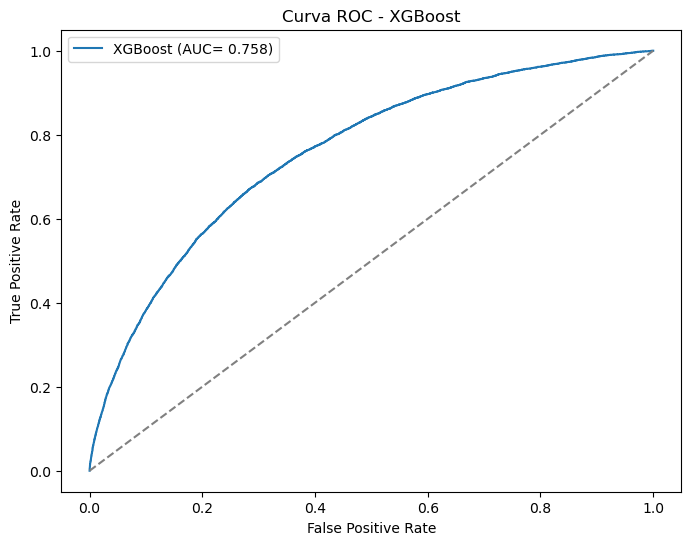

In [18]:
fpr, tpr, _ = roc_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC= {roc_auc_score(y_teste, y_proba_xgb):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')

plt.show()

## 4.6 Curva Precision-Recall

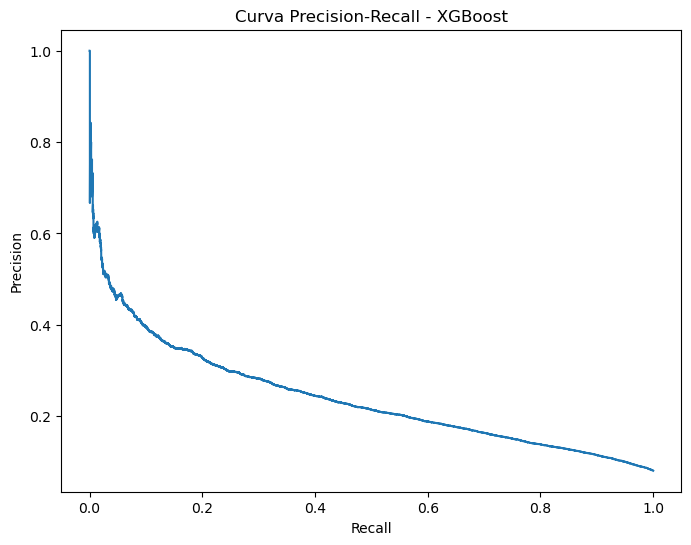

In [19]:
precision, recall, _ = precision_recall_curve(
    y_teste,
    y_proba_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - XGBoost')

plt.show()

## 4.7 Validação Cruzada

## 4.8 K-Fold Cross Validation

## 4.9 Avaliação dos Resultados

## 5.0 Interpretação

# 5.1 Otimização de Hiperparâmetros

## 5.2 Definição do Espaço de Busca
Para otimizar o desempenho do XGBoost, foi definido um conjunto de hiperparâmetros candidatos para exploração.

Os parâmetros selecionados possuem influência direta sobre a complexidade do modelo, capacidade de generalização e equilíbrio entre underfitting e overfitting.

A busca será realizada por meio de RandomizedSearchCV, permitindo explorar diferentes combinações de forma eficiente.

In [47]:
# INTERVALO DOS PARAMETROS QUE SERÃO UTILIZADOS NO RANDOMIZEDSEARCHCV
parametros = {

    'n_estimators': [100, 200, 300, 500],

    'max_depth': [3, 4, 5, 6, 8],

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'subsample': [0.7, 0.8, 0.9, 1.0],

    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],

    'min_child_weight': [1, 3, 5],

    'gamma': [0, 0.1, 0.2, 0.3],
    
    'scale_pos_weight': [8,10,12,14],
    
    'eval_metric': ['logloss']
}

## 5.3 RandomizedSearchCV

In [48]:
# CRIANDO O ALGORIMO PADRÃO
xgb = XGBClassifier(random_state = 0)

# CRIANDO O RANDOM_SEARCH, O ALGORITMO UTILIZADO É O XGB, INTERVALO DE PARAMETROS DEFINIDOS NO PASSO ANTERIOR
# 30 INTERAÇÕES, PRINCIPAL METRICA DE DECISÃO BUSCADA = 'ROC_AUC'. quantidade de voltas no kfold
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parametros,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=0,
    n_jobs=-1
)

## 5.4 Melhor configuração encontrada

In [49]:
# EXECUTANDO O RANDOM_SEARCH PARA BUSCAR OS MELHORES PARAMETROS
random_search.fit(x_treino, y_treino)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'eval_metric': ['logloss'], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [50]:
# EXTRAINDO OS MELHORES PARAMETROS E O MELHOR AUC-ROC OBTIDO
melhores_parametros = random_search.best_params_
melhor_score = random_search.best_score_
print(f'Melhores parametros: {melhores_parametros}')
print(f'Melhor AUC-ROC obtido: {melhor_score:.2f}')

Melhores parametros: {'subsample': 0.9, 'scale_pos_weight': 8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'eval_metric': 'logloss', 'colsample_bytree': 1.0}
Melhor AUC-ROC obtido: 0.76


## 5.5 Avaliação do Modelo Otimizado

In [51]:
y_pred_random = random_search.predict(x_teste)
y_proba_random = random_search.predict_proba(x_teste)[:,1]

print(y_pred_random)
print(y_proba_random)

[1 1 0 ... 0 1 0]
[0.60402715 0.6404323  0.27630657 ... 0.3389204  0.6678469  0.29457137]


## 5.6 Classification Report

In [52]:
print(classification_report(y_teste, y_pred_random))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     84806
           1       0.20      0.54      0.30      7448

    accuracy                           0.79     92254
   macro avg       0.58      0.68      0.59     92254
weighted avg       0.89      0.79      0.83     92254



## 5.7 Matriz de Confusão

In [53]:
print(confusion_matrix(y_teste,y_pred_random))

[[69117 15689]
 [ 3407  4041]]


## 5.8 AUC-ROC

## 5.9 Curva-ROC

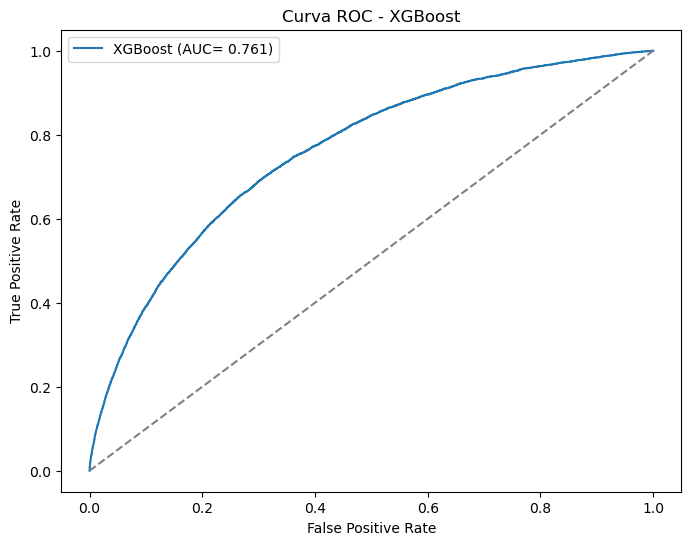

In [56]:
fpr, tpr, _ = roc_curve(
    y_teste,
    y_proba_random
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC= {roc_auc_score(y_teste, y_proba_random):.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')

plt.show()

## 6. Curva Precision-Recall

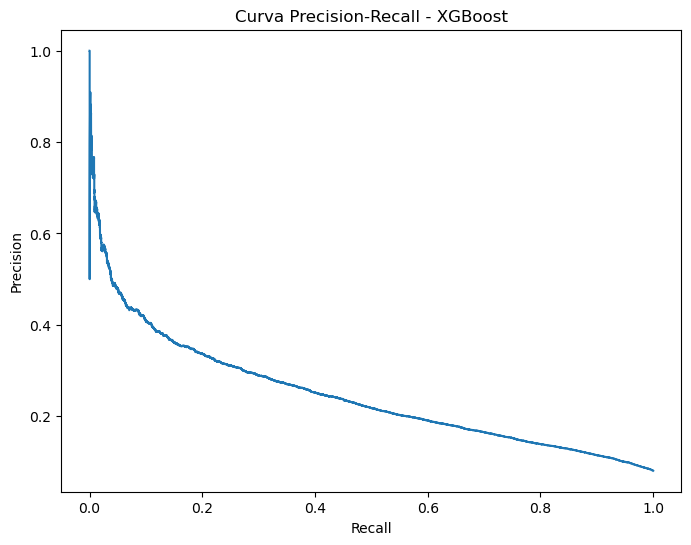

In [54]:
precision, recall, _ = precision_recall_curve(
    y_teste,
    y_proba_random
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Curva Precision-Recall - XGBoost')

plt.show()

## 7. Ajustes de Threshold de Classificação

Conforme observado anteriormente, o limiar padrão de classificação pode não representar o melhor equilíbrio entre Recall e Precision em problemas de risco de crédito.

# 8. Importância das Variáveis

A análise da importância das variáveis permite identificar quais atributos exercem maior influência sobre a previsão de inadimplência.

## 8.1 Ranking das Features

## 8.2 Visualização Gráfica

## 8.3 Interpretação

# 9. Comparação Final

Comparação do Modelo Original e do Modelo Otimizado

# 10. Conclusões

Avaliação dos ganhos obtidos com validação cruzada, otimização dos hiperparâmetros e ajuste do threshold de classificação.

# 11. Próximos Passos

- Consolidação dos resultados finais do projeto
- Interpretação de negócio das variáveis mais relevantes
- Desenvolvimento de Dashboard para visualização dos resultados
- Preparação dos artefatos para publicação e portifólio